# RQ2: Can LLMs infer the granularity of human taxonomies from unlabeled data?

**The grid.** 8 k-inference methods x 10 seeds x the **19 RQ1-clean benchmarks**
(benchmark k 5-151), Gemini 2.5 Flash temp 0, criteria verbatim from
`research_question_3_clean/criteria.json`. No method sees labels, benchmark k, or a
granularity hint. Geometry (judge_sweep, pairwise, merge_conv) uses INSTRUCTOR-large
with the generic instruction; every method that selects among candidate k values uses
one shared grid, 25 log-spaced points on [2, 200] (23 unique). merge_conv starts from
k0 = 200 (the grid maximum). codebook and judge_sweep reuse the ten RQ1-clean judge
runs, so they are RQ1's instrument by construction.

**vs the old study:** 14 -> 19 corpora, criteria unified with RQ1, one shared grid,
merge_conv's corpus-size cap (k0 = min(50, N/20)) replaced by the flat grid maximum.
7 of 1,520 runs (6 direct, 1 probe) failed deterministically on thinking-budget
truncation and are reported as missing.

In [1]:
import zlib
from pathlib import Path

import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib as mpl

REPO = Path.cwd().parents[1]              # repo root (this notebook lives in analysis/rq2/)
DATA = REPO / 'data' / 'rq2'
RESULTS = REPO / 'results' / 'rq2'
FIGS = REPO / 'figures'

runs = pd.read_csv(DATA / 'llm_k_runs.csv')
meta = pd.read_csv(RESULTS / 'suite_meta.csv').set_index('bench')
runs['gold_k'] = runs.bench.map(meta.gold_k)
runs['log2_ratio'] = np.log2(runs.k / runs.gold_k)

DISPL = {'banking77': 'Banking77', 'clinc150': 'CLINC(I)', 'clinc150_domain': 'CLINC(D)',
         'mtop_intent': 'MTOP(I)', 'mtop_domain': 'MTOP(D)', 'massive_intent': 'MASSIVE(I)',
         'massive_domain': 'MASSIVE(D)', 'tweet89': 'Tweet89', 'stackoverflow20': 'StackOverflow',
         'mcid': 'M-CID', 'snips': 'SNIPS', 'dbpedia': 'DBPedia', 'reddit_s2s': 'Reddit-S2S',
         'arxiv_fine': 'ArXiv-S2S', 'stackexchange_cl': 'StackEx-S2S', 'fewrel': 'FewRel',
         'fewnerd': 'FewNerd', 'fewevent': 'FewEvent', 'bbcnews': 'BBC News'}

mpl.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.edgecolor': 'black', 'axes.linewidth': .8, 'figure.dpi': 120})
MCOL = {'codebook': '#8E44AD', 'direct': '#E8912D', 'probe': '#16A085',
        'pairwise': '#6699CC', 'sequential': '#B5A642', 'simpson': '#5D4037',
        'judge_sweep': '#2C3E50', 'merge_conv': '#E75480'}
METHODS = [m for m in MCOL if m in set(runs.method)]
JIT = {m: -0.32 + 0.64 * i / max(len(METHODS) - 1, 1) for i, m in enumerate(METHODS)}

def save(fig, stem):
    fig.savefig(FIGS / f'{stem}.pdf', bbox_inches='tight')
    print(f'saved figures/{stem}.pdf')


## Verdict

No method reliably recovers human taxonomy granularity. The best calibrated methods
(direct, simpson, codebook) land within a factor of two of gold on ~58-63% of corpora
against ~53% for the best fixed constant, a corpus-specific gain of only a few
points, and every method compresses the fine-grained tail (gold 77-151) into a
coarse band. Methods disagree with each other by a median of ~4 octaves on the same
corpus with the same criterion, and most are unstable across seeds (spread ~1 means
the estimate swings by its own size). merge_conv, the most stable method, is stably
wrong: it reproduces its starting segmentation, not the corpus. With the same corpora
carrying several legitimate benchmark granularities (MASSIVE 18/59, MTOP 11/102, CLINC
10/151), granularity is a specification, not an estimand; expose it as a
user-controlled parameter, exactly as RQ1's judge and RQ3's pipeline consume it.

In [2]:
# EXHIBIT 1: the scoreboard (thesis table). Academic-standard construction:
# booktabs LaTeX (no vertical rules), direction arrows in headers, best value per
# metric in bold, rows grouped pure-LLM / hybrid / baseline; the Wilcoxon test vs
# the baseline is summarised in the caption and printed below. Emitted as LaTeX and
# as CSV; the printed frame below mirrors it.
from scipy.stats import wilcoxon

med = runs.groupby(['method', 'bench']).agg(km=('k', 'median'),
                                            g=('gold_k', 'first')).reset_index()
med['e'] = np.log2(med.km / med.g)
gold = meta.gold_k.values

# Gold-blind baseline: silhouette-argmax under the SAME 10-seed protocol as the
# methods (data/silhouette_baseline_seeds.csv, script 03_silhouette_seeds.py).
# Per corpus: median estimate over the 10 seeds, plus min/max for spread/whiskers.
SILS = pd.read_csv(DATA / 'silhouette_baseline_seeds.csv')
gs = SILS.groupby('bench')
SIL = pd.DataFrame({'k_sil': gs.k_sil.median(), 'gold': gs.gold.first(),
                    'k_min': gs.k_sil.min(), 'k_max': gs.k_sil.max()}) \
        .loc[sorted(meta.index)]
sil_e = np.log2(SIL.k_sil.values / SIL.gold.values)
sil_spread = float(((SIL.k_max - SIL.k_min) / SIL.k_sil).median())

PURE = ['codebook', 'direct', 'probe', 'pairwise', 'sequential', 'simpson']
HYB = ['judge_sweep', 'merge_conv']
NAME = {'codebook': 'Codebook', 'direct': 'Direct', 'probe': 'Probe',
        'pairwise': 'Pairwise', 'sequential': 'Sequential', 'simpson': 'Simpson',
        'judge_sweep': 'Judge sweep', 'merge_conv': 'Merge convergence'}

T15 = np.log2(1.5)

def ccc(x, y):
    """Lin's concordance correlation coefficient (agreement with y = x)."""
    mx, my = x.mean(), y.mean()
    return (2 * np.cov(x, y)[0, 1] * (len(x) - 1) / len(x)
            / (x.var() + y.var() + (mx - my) ** 2))

S = {}
for m, g in med.groupby('method'):
    p = wilcoxon(np.abs(g.e.values), np.abs(sil_e)).pvalue
    sp = runs[runs.method == m].groupby('bench').k.agg(
        lambda d: (d.max() - d.min()) / d.median()).median()
    S[m] = {'w15': int((g.e.abs() <= T15).sum()),
            'w10': int(((g.km / g.g - 1).abs() <= 0.10).sum()),
            'mae': g.e.abs().median(), 'bias': g.e.median(),
            'ccc': ccc(np.log2(g.g.values.astype(float)),
                       np.log2(g.km.values.astype(float))),
            'spread': sp, 'p': p}
BSIL = {'w15': int((np.abs(sil_e) <= T15).sum()),
        'w10': int((np.abs(SIL.k_sil.values / SIL.gold.values - 1) <= 0.10).sum()),
        'mae': float(np.median(np.abs(sil_e))),
        'bias': float(np.median(sil_e)),
        'ccc': ccc(np.log2(SIL.gold.values.astype(float)),
                   np.log2(SIL.k_sil.values.astype(float))),
        'spread': sil_spread}

best = {'w15': max(S[m]['w15'] for m in S), 'w10': max(S[m]['w10'] for m in S),
        'mae': min(S[m]['mae'] for m in S),
        'ccc': max(S[m]['ccc'] for m in S)}

def row(m):
    s = S[m]
    w15 = f"{s['w15']}/19"
    if s['w15'] == best['w15']: w15 = f'\\textbf{{{w15}}}'
    w10 = f"{s['w10']}/19"
    if s['w10'] == best['w10']: w10 = f'\\textbf{{{w10}}}'
    mae = f"{s['mae']:.2f}"
    if abs(s['mae'] - best['mae']) < 1e-9: mae = f'\\textbf{{{mae}}}'
    cc = f"{s['ccc']:.2f}"
    if abs(s['ccc'] - best['ccc']) < 1e-9: cc = f'\\textbf{{{cc}}}'
    return (f"{NAME[m]} & {w15} & {w10} & {mae} & {cc} & "
            f"{s['spread']:.2f} \\\\")

lines = [
    '\\begin{table}[htbp]', '\\centering', '\\small',
    '\\begin{tabular}{lccccc}', '\\toprule',
    'Method & Within $1.5\\times$ & Within $\\pm10\\%$'
    ' & Med.\\ $|\\varepsilon|$ & CCC'
    ' & Spread \\\\',
    '\\midrule']
lines += [row(m) for m in PURE + HYB]
lines += ['\\midrule',
          f"Silhouette-argmax (no LLM) & {BSIL['w15']}/19 & {BSIL['w10']}/19"
          f" & {BSIL['mae']:.2f}"
          f" & {BSIL['ccc']:.2f} & {BSIL['spread']:.2f} \\\\",
          '\\bottomrule', '\\end{tabular}',
          '\\caption{Granularity estimation on the 19-benchmark suite. Bold marks'
          ' the best method on each accuracy statistic; the bottom row is the'
          ' LLM-free silhouette-argmax baseline.}',
          '\\label{tab:rq2-scoreboard}', '\\end{table}']
tex = '\n'.join(lines)
(RESULTS / 'table_T2.tex').write_text(tex)

T2 = pd.DataFrame([{'method': NAME[m], 'w1.5x': f"{S[m]['w15']}/19",
                    'w10pct': f"{S[m]['w10']}/19",
                    'med_abs_e': round(S[m]['mae'], 2),
                    'CCC': round(S[m]['ccc'], 2),
                    'spread': round(S[m]['spread'], 2)}
                   for m in PURE + HYB]
                  + [{'method': 'Silhouette-argmax (no LLM)',
                      'w1.5x': f"{BSIL['w15']}/19", 'w10pct': f"{BSIL['w10']}/19",
                      'med_abs_e': round(BSIL['mae'], 2),
                      'CCC': round(BSIL['ccc'], 2),
                      'spread': round(BSIL['spread'], 2)}])
T2.to_csv(RESULTS / 'table_T2.csv', index=False)
print(T2.to_string(index=False))
pmin = min(S[m]['p'] for m in S)
over = [NAME[m] for m in PURE + HYB if S[m]['bias'] > 0]
print(f'\novershooting methods (positive median signed error): {over}')
print(f'\npaired Wilcoxon vs silhouette baseline: all p >= {pmin:.2f} '
      '(no method significantly different)')
print('\nwrote results/table_T2.tex (booktabs) and table_T2.csv')

                    method w1.5x w10pct  med_abs_e  CCC  spread
                  Codebook  7/19   2/19       0.81 0.54    1.09
                    Direct  9/19   2/19       0.61 0.57    1.09
                     Probe  6/19   2/19       1.61 0.05    1.04
                  Pairwise  8/19   3/19       1.10 0.62    0.57
                Sequential  5/19   2/19       0.84 0.48    1.14
                   Simpson  5/19   4/19       0.83 0.42    1.03
               Judge sweep  6/19   1/19       0.94 0.54    1.09
         Merge convergence  1/19   0/19       1.73 0.13    0.17
Silhouette-argmax (no LLM)  9/19   4/19       1.15 0.19    1.06

overshooting methods (positive median signed error): ['Pairwise', 'Sequential', 'Merge convergence']

paired Wilcoxon vs silhouette baseline: all p >= 0.12 (no method significantly different)

wrote results/table_T2.tex (booktabs) and table_T2.csv


saved figures/rq2c_ex2_calibration.pdf


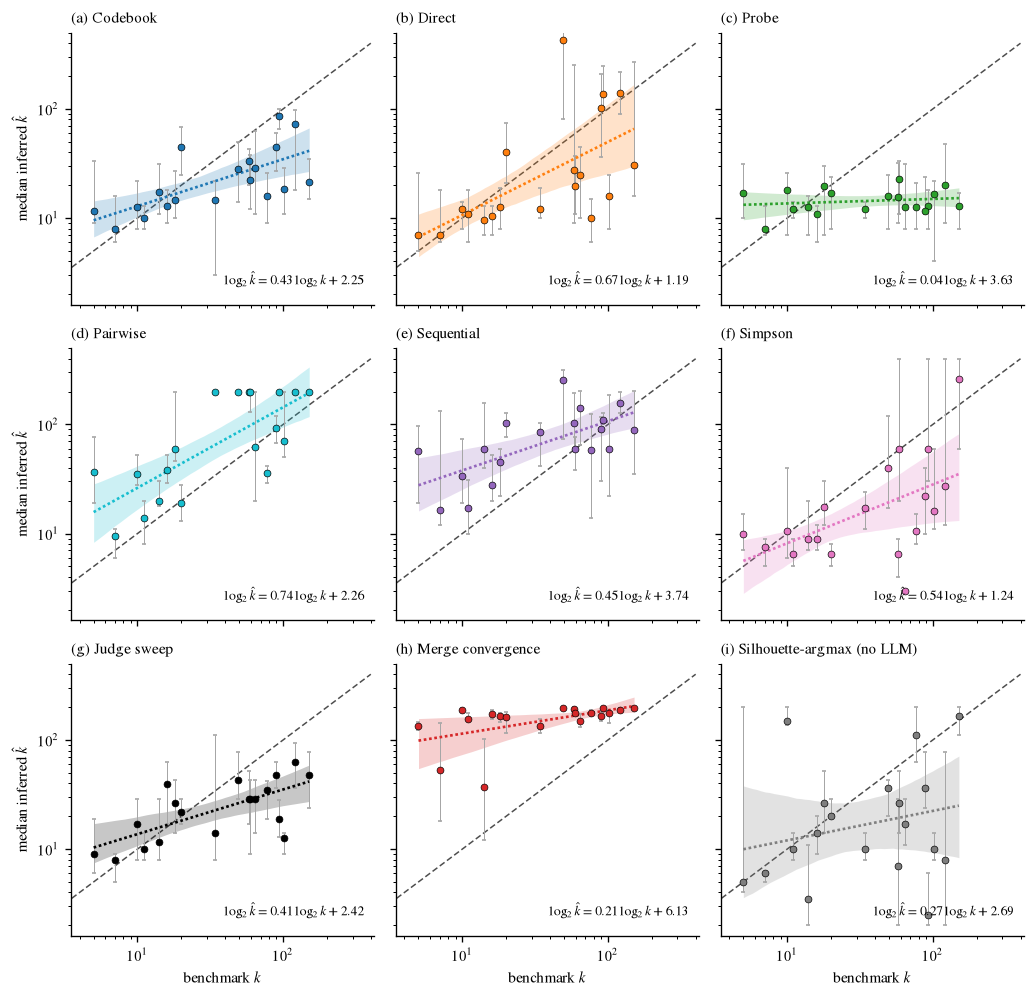

In [3]:
# EXHIBIT 2: calibration panels (thesis main figure). Academic conventions: serif
# fonts to match the document body, no in-figure title (the caption carries it),
# lettered panels, Okabe-Ito colourblind-safe palette, dashed y=x reference, light
# neutral factor-2 band, vector PDF.
OKABE = {'codebook': '#1f77b4', 'direct': '#ff7f0e', 'probe': '#2ca02c',
         'pairwise': '#17becf', 'sequential': '#9467bd', 'simpson': '#e377c2',
         'judge_sweep': '#000000', 'merge_conv': '#d62728',
         'silhouette': '#7f7f7f'}
NAME['silhouette'] = 'Silhouette-argmax (no LLM)'
_RCA = {'font.family': 'serif', 'mathtext.fontset': 'stix',
        'font.serif': ['STIXGeneral', 'Times New Roman', 'DejaVu Serif'],
        'axes.linewidth': 0.8, 'font.size': 9}
lohi = runs.groupby(['method', 'bench']).k.agg(['min', 'max']).reset_index()
M = med.merge(lohi, on=['method', 'bench'])
sil_g = pd.DataFrame({'g': SIL.gold.values.astype(float),
                      'km': SIL.k_sil.values.astype(float),
                      'min': SIL.k_min.values.astype(float),
                      'max': SIL.k_max.values.astype(float)})
PANEL = PURE + HYB + ['silhouette']

with plt.rc_context(_RCA):
    fig, axs = plt.subplots(3, 3, figsize=(8.7, 8.4), sharex=True, sharey=True)
    gg = np.array([2, 400])
    for li, (ax, m) in enumerate(zip(axs.ravel(), PANEL)):
        g = sil_g if m == 'silhouette' else M[M.method == m]
        ax.plot(gg, gg, color='0.3', lw=0.9, ls=(0, (4, 2)), zorder=1)
        ax.errorbar(g.g, g.km, yerr=[g.km - g['min'], g['max'] - g.km],
                    fmt='none', ecolor='0.65', elinewidth=.6, capsize=1.2,
                    zorder=2)
        ax.scatter(g.g, g.km, s=17, color=OKABE[m], edgecolor='black', lw=.4, zorder=3)
        x2, y2 = np.log2(g.g.values), np.log2(g.km.values)
        slope, icpt = np.polyfit(x2, y2, 1)
        xf = np.geomspace(g.g.min(), g.g.max(), 50)
        # 95% band: bootstrap over corpora, same resampling scheme as the table CI
        rng_fit = np.random.RandomState(1)
        idx = rng_fit.randint(0, len(x2), (2000, len(x2)))
        coefs = np.array([np.polyfit(x2[i], y2[i], 1) for i in idx])
        fits = np.array([np.polyval(c, np.log2(xf)) for c in coefs])
        lo_f, hi_f = np.percentile(fits, [2.5, 97.5], axis=0)
        ci = (np.percentile(coefs[:, 0], 97.5) - np.percentile(coefs[:, 0], 2.5)) / 2
        ax.fill_between(xf, 2 ** lo_f, 2 ** hi_f, color=OKABE[m], alpha=0.22,
                        lw=0, zorder=1.5)
        ax.plot(xf, 2 ** (icpt + slope * np.log2(xf)), color=OKABE[m], lw=1.6,
                ls=(0, (1, 1)), zorder=2.5)
        ax.set_title(f'({chr(97 + li)}) {NAME[m]}', fontsize=9, loc='left')
        ax.text(0.97, 0.06,
                f'$\\log_2 \\hat{{k}} = {slope:.2f}\\,\\log_2 k {icpt:+.2f}$',
                transform=ax.transAxes, fontsize=8, ha='right', va='bottom')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlim(3.5, 420); ax.set_ylim(1.6, 500)
        for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
    for ax in axs[-1]: ax.set_xlabel('benchmark $k$')
    for ax in axs[:, 0]: ax.set_ylabel('median inferred $\\hat{k}$')
    plt.tight_layout()
    save(fig, 'rq2c_ex2_calibration')
    plt.show()